# Fig 3

In [19]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src.models import Transformer
from src.datasets.CopyFirstLastICLDataset import CopyFirstLastICLDataset
from src.plot_utils import format_axis

RESULTS_ROOT = Path('../../../results/icl_copy_firstlast/runs')
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {device}')

Device: cuda


In [20]:
GROUP_DIRS = [
    RESULTS_ROOT / "20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds",
    RESULTS_ROOT / "20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds",
]

MIN_ACC = 0.90

frac_labels = {
    0.1: 'Copy-last early (start=0.1)',
    0.5: 'Equal (start=0.5)',
}


def load_group_results(group_dir: Path, min_acc: float = MIN_ACC) -> list:
    seed_results = []
    skipped = 0
    for seed_dir in sorted(group_dir.iterdir()):
        if not seed_dir.is_dir() or not seed_dir.name.startswith('seed_'):
            continue
        rf = seed_dir / 'results.json'
        if not rf.exists():
            continue
        with open(rf) as f:
            data = json.load(f)
        pt = data['pretraining']
        if max(pt['copy_first_accuracy']) < min_acc or max(pt['copy_last_accuracy']) < min_acc:
            skipped += 1
            continue
        data['_source_dir'] = str(seed_dir)
        seed_results.append(data)
    print(f'Loaded {len(seed_results)} seeds from {group_dir.name} (skipped {skipped})')
    return seed_results


def setup_seed(r: dict, device: torch.device):
    config = r['config']
    model_config = config['model']
    source_dir = Path(r['_source_dir'])
    checkpoint = torch.load(source_dir / 'pretrained_checkpoint.pt', map_location=device)
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in checkpoint['model_state_dict'].items()}
    model = Transformer(**model_config)
    model.load_state_dict(state_dict)
    model = model.to(device).eval()
    eval_dataset = CopyFirstLastICLDataset(
        n_sequences=500,
        symbol_vocab_size=config['symbol_vocab_size'],
        feature_len=config['feature_len'],
        n_context_examples=config['n_context_examples'],
        task_distribution={'copy_first': 0.5, 'copy_last': 0.5},
        mode='standard',
        seed=config['seed'] + 1000,
    )
    return model, eval_dataset, config

In [21]:
all_seeds = {}
for group_dir in GROUP_DIRS:
    seed_results = load_group_results(group_dir)
    if not seed_results:
        continue
    frac = seed_results[0]['config']['start_copy_first_frac']
    all_seeds[frac] = seed_results
print(f'Groups loaded: {list(all_seeds.keys())}')

Loaded 8 seeds from 20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds (skipped 22)
Loaded 30 seeds from 20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds (skipped 0)
Groups loaded: [0.5, 0.1]


In [22]:
@torch.no_grad()
def head_logit_attribution(model, input_ids, correct_tokens, batch_size=64):
    """
    Direct logit attribution (DLA) at the query colon position.

    DLA_i = (W_U * gamma) . c_i / scale(h)
    where c_i = component i output at query colon,
          scale(h) = std of full residual h (from LN denominator),
          gamma = LN weight.

    Returns dict: component_name -> (n_sequences,) contribution toward correct token.
    """
    model.eval()
    n_seq    = input_ids.shape[0]
    n_layers = len(model.blocks)

    W_U  = model.lm_head.weight   # (vocab, d_model)
    gamma = model.ln_f.weight     # (d_model,)
    W_Ug  = W_U * gamma.unsqueeze(0)  # (vocab, d_model)

    comp_keys = ['embed'] + [f'block{i}_{t}' for i in range(n_layers) for t in ['attn', 'ffn']]
    all_contribs = {k: [] for k in comp_keys}

    for start in range(0, n_seq, batch_size):
        end  = min(start + batch_size, n_seq)
        ids  = input_ids[start:end].to(device)
        tgts = correct_tokens[start:end].to(device)
        b    = ids.shape[0]

        tok_emb = model.token_emb(ids)
        if model.use_learned_pe:
            positions = torch.arange(ids.shape[1], device=device)
            x = tok_emb + model.pos_enc(positions)
        else:
            x = model.pos_enc(tok_emb)
        x = model.dropout(x)

        comp = {'embed': x[:, -1, :].clone()}
        for i, block in enumerate(model.blocks):
            attn_out = block.attn(block.ln1(x))
            comp[f'block{i}_attn'] = attn_out[:, -1, :].clone()
            x = x + attn_out
            ffn_out = block.ff(block.ln2(x))
            comp[f'block{i}_ffn'] = ffn_out[:, -1, :].clone()
            x = x + ffn_out

        # LN scale from full residual
        h     = x[:, -1, :]
        var_h = h.var(dim=-1, unbiased=False, keepdim=True)
        scale = torch.sqrt(var_h + model.ln_f.eps)

        for name in comp_keys:
            c = comp[name]
            logit_contribs = (c / scale) @ W_Ug.T      # (batch, vocab)
            contrib = logit_contribs[torch.arange(b), tgts]
            all_contribs[name].append(contrib.cpu().numpy())

    return {k: np.concatenate(v) for k, v in all_contribs.items()}

In [23]:
attr_data = {}

for frac in sorted(all_seeds.keys()):
    label = frac_labels.get(frac, str(frac))
    print(f'\n{label}')

    seed_records = []
    for r in all_seeds[frac]:
        model, eval_dataset, config = setup_seed(r, device)
        all_ids  = eval_dataset.sequences.to(device)
        all_tgts = eval_dataset.standard_targets
        cf_idx   = eval_dataset.get_copy_first_indices().numpy()
        cl_idx   = eval_dataset.get_copy_last_indices().numpy()
        contribs = head_logit_attribution(model, all_ids, all_tgts)
        contribs['cf_idx'] = cf_idx
        contribs['cl_idx'] = cl_idx
        seed_records.append(contribs)
        print(f'  seed done')

    attr_data[frac] = {'label': label, 'seeds': seed_records}

print('\nDone.')


Copy-last early (start=0.1)
  seed done
  seed done


/tmp/ipykernel_4054196/1909021021.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(source_dir / 'pretrained_checkpoint.pt', map_location=device)


  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done

Equal (start=0.5)
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done
  seed done

Done.


In [24]:
def plot_multi_seed_ablations(all_seed_results):
    meta    = all_seed_results[0]['meta']
    conds   = meta['abl_conditions']
    n_seeds = len(all_seed_results)

    # Filter to only Baseline + attention ablations
    keep_idx = [i for i, c in enumerate(conds) if c is None or c.endswith('_attn')]

    cond_labels = []
    for i in keep_idx:
        c = conds[i]
        if c is None:
            cond_labels.append('Baseline')
        else:
            parts = c.split('_')
            cond_labels.append(f"B{parts[0].replace('block','')} ATTN")

    cf_arr = np.stack([sr['ablations']['copy_first_acc'] for sr in all_seed_results])[:, keep_idx] * 100
    cl_arr = np.stack([sr['ablations']['copy_last_acc'] for sr in all_seed_results])[:, keep_idx] * 100

    x     = np.arange(len(keep_idx))
    width = 0.3
    cf_mean, cf_std = cf_arr.mean(0), cf_arr.std(0)
    cl_mean, cl_std = cl_arr.mean(0), cl_arr.std(0)

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.bar(x - width/2, cf_mean, width, yerr=cf_std, capsize=4,
           label='Copy First', color='#e74c3c', alpha=0.8, error_kw={'linewidth': 1.5})
    ax.bar(x + width/2, cl_mean, width, yerr=cl_std, capsize=4,
           label='Copy Last', color='#3498db', alpha=0.8, error_kw={'linewidth': 1.5})

    # Individual seed data points with jitter
    rng = np.random.default_rng(0)
    jitter_scale = 0.06
    for seed_i in range(n_seeds):
        jitter = rng.uniform(-jitter_scale, jitter_scale)
        ax.scatter(x - width/2 + jitter, cf_arr[seed_i], color='black',
                   s=20, alpha=0.5, zorder=5, edgecolors='none')
        ax.scatter(x + width/2 + jitter, cl_arr[seed_i], color='black',
                   s=20, alpha=0.5, zorder=5, edgecolors='none')

    ax.set_xticks(x)
    ax.set_xticklabels(cond_labels, fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Mean-Ablation Results (mean \u00b1 std, n={n_seeds})')
    ax.set_ylim(0, 120)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    format_axis(ax)
    plt.tight_layout()
    return fig

In [25]:
@torch.no_grad()
def compute_mean_components(model, all_input_ids, batch_size=64):
    """Compute mean attention/FFN output at each block (for mean ablation)."""
    model.eval()
    sums, n_total = {}, 0
    for start in range(0, all_input_ids.shape[0], batch_size):
        end = min(start + batch_size, all_input_ids.shape[0])
        input_ids = all_input_ids[start:end]
        batch, seq_len = input_ids.shape
        n_total += batch
        tok_emb = model.token_emb(input_ids)
        if model.use_learned_pe:
            positions = torch.arange(seq_len, device=input_ids.device)
            x = tok_emb + model.pos_enc(positions)
        else:
            x = model.pos_enc(tok_emb)
        x = model.dropout(x)
        for i, block in enumerate(model.blocks):
            attn_out = block.attn(block.ln1(x))
            x = x + attn_out
            ffn_out = block.ff(block.ln2(x))
            x = x + ffn_out
            for key, out in [(f'block{i}_attn', attn_out), (f'block{i}_ffn', ffn_out)]:
                if key not in sums:
                    sums[key] = torch.zeros_like(out[0])
                sums[key] += out.sum(0)
    return {k: v / n_total for k, v in sums.items()}


@torch.no_grad()
def ablated_forward(model, input_ids, ablate, mean_components):
    """Forward pass with one component replaced by its dataset-mean activation."""
    model.eval()
    batch, seq_len = input_ids.shape
    tok_emb = model.token_emb(input_ids)
    if model.use_learned_pe:
        positions = torch.arange(seq_len, device=input_ids.device)
        x = tok_emb + model.pos_enc(positions)
    else:
        x = model.pos_enc(tok_emb)
    x = model.dropout(x)
    for i, block in enumerate(model.blocks):
        attn_out = block.attn(block.ln1(x))
        if ablate == f'block{i}_attn':
            attn_out = mean_components[f'block{i}_attn'].unsqueeze(0).expand(batch, -1, -1)
        x = x + attn_out
        ffn_out = block.ff(block.ln2(x))
        if ablate == f'block{i}_ffn':
            ffn_out = mean_components[f'block{i}_ffn'].unsqueeze(0).expand(batch, -1, -1)
        x = x + ffn_out
    return model.lm_head(model.ln_f(x))[:, -1, :]

def run_analysis_for_seed(r: dict, device: torch.device, batch_size: int = 64) -> dict:
    """
    Run logit lens, linear probing, and ablations for one seed.
    Returns a dict of numpy arrays ready for multi-seed aggregation.
    """
    model, dataset, config = setup_seed(r, device)
    feature_len = config['feature_len']
    n_layers = len(model.blocks)

    all_ids = dataset.sequences.to(device)
    all_tgts = dataset.standard_targets.to(device)
    cf_idx = dataset.get_copy_first_indices().numpy()
    cl_idx = dataset.get_copy_last_indices().numpy()

    ll_layer_names    = ['embed'] + [f'block{i}' for i in range(n_layers)]
    probe_layer_names = ['embed'] + sum([[f'block{i}_attn', f'block{i}'] for i in range(n_layers)], [])
    abl_conditions    = [None] + [f'block{i}_{c}' for i in range(n_layers) for c in ['attn', 'ffn']]

 

    # ── 3. Component Ablations ───────────────────────────────────────────────
    print("  Running ablations...")
    mean_comp = compute_mean_components(model, all_ids, batch_size)

    cf_accs, cl_accs = [], []
    for cond in abl_conditions:
        cf_c = cf_n = cl_c = cl_n = 0
        for start in range(0, len(dataset), batch_size):
            end   = min(start + batch_size, len(dataset))
            ids   = all_ids[start:end]
            tgts  = all_tgts[start:end]
            tasks = [dataset.tasks[j] for j in range(start, end)]
            logits = (model(ids)[:, -1, :] if cond is None
                      else ablated_forward(model, ids, cond, mean_comp))
            preds = logits.argmax(-1)
            for j, task in enumerate(tasks):
                correct = (preds[j] == tgts[j]).item()
                if task == 'copy_first': cf_c += correct; cf_n += 1
                else:                    cl_c += correct; cl_n += 1
        cf_accs.append(cf_c / cf_n)
        cl_accs.append(cl_c / cl_n)

    return {
        'ablations':  {'copy_first_acc': np.array(cf_accs), 'copy_last_acc': np.array(cl_accs)},
        'meta': {
            'll_layer_names':    ll_layer_names,
            'probe_layer_names': probe_layer_names,
            'abl_conditions':    abl_conditions,
            'n_layers':          n_layers,
        },
    }

In [26]:
frac_labels = {
    0.1: 'Copy-last early (start_copy_first=0.1)',
    0.5: 'Equal (start_copy_first=0.5)',
}
# Run analyses for all groups — results stored in all_analysis dict
all_analysis = {}
for group_dir in GROUP_DIRS:
    seed_results = load_group_results(group_dir)
    if not seed_results:
        print(f"  No valid seeds in {group_dir.name}, skipping.")
        continue

    frac = seed_results[0]['config']['start_copy_first_frac']
    label = frac_labels.get(frac, f'start_copy_first_frac={frac}')

    print(f"\n{'='*70}")
    print(f"  {label}  ({len(seed_results)} seeds)")
    print(f"{'='*70}")

    seed_analysis = []
    for i, r in enumerate(seed_results):
        print(f"\n── Seed {i+1}/{len(seed_results)}  (seed={r['config']['seed']}) ──")
        seed_analysis.append(run_analysis_for_seed(r, device))

    all_analysis[frac] = {'label': label, 'seed_analysis': seed_analysis}

print(f"\nDone. Computed analyses for fracs: {list(all_analysis.keys())}")

Loaded 8 seeds from 20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds (skipped 22)

  Equal (start_copy_first=0.5)  (8 seeds)

── Seed 1/8  (seed=56) ──
  Running ablations...


/tmp/ipykernel_4054196/1909021021.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(source_dir / 'pretrained_checkpoint.pt', map_location=device)



── Seed 2/8  (seed=58) ──
  Running ablations...

── Seed 3/8  (seed=62) ──
  Running ablations...

── Seed 4/8  (seed=63) ──
  Running ablations...

── Seed 5/8  (seed=66) ──
  Running ablations...

── Seed 6/8  (seed=68) ──
  Running ablations...

── Seed 7/8  (seed=69) ──
  Running ablations...

── Seed 8/8  (seed=70) ──
  Running ablations...
Loaded 30 seeds from 20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds (skipped 0)

  Copy-last early (start_copy_first=0.1)  (30 seeds)

── Seed 1/30  (seed=50) ──
  Running ablations...

── Seed 2/30  (seed=51) ──
  Running ablations...

── Seed 3/30  (seed=52) ──
  Running ablations...

── Seed 4/30  (seed=53) ──
  Running ablations...

── Seed 5/30  (seed=54) ──
  Running ablations...

── Seed 6/30  (seed=55) ──
  Running ablations...

── Seed 7/30  (seed=56) ──
  Running ablations...

── Seed 8/30  (seed=57) ──
  Running ablations...

── Seed 9/30  (seed=58) ──
  Running ablations...

── Seed 10/30  (seed=59) ──
  Running

In [ ]:
from einops import rearrange


def make_label_flipped_sequences(sequences, dataset):
    """Return a copy of sequences with each context label flipped to the opposite feature endpoint."""
    feature_len = dataset.feature_len
    n_context   = dataset.n_context_examples
    block_len   = feature_len + 3  # feature + colon + label + sep
    label_positions = [ctx * block_len + feature_len + 1 for ctx in range(n_context)]

    flipped = sequences.clone()
    for i in range(len(sequences)):
        for lp in label_positions:
            feat_start = lp - feature_len - 1
            first_tok  = sequences[i, feat_start].item()
            last_tok   = sequences[i, feat_start + feature_len - 1].item()
            cur_label  = sequences[i, lp].item()
            flipped[i, lp] = last_tok if cur_label == first_tok else first_tok
    return flipped


@torch.no_grad()
def activation_patching_forward(model, clean_ids, corrupted_ids, patch_component, batch_size=64):
    """
    Run clean forward pass, patching one component's output from the corrupted run.
    patch_component: one of 'block0_attn', 'block0_ffn', 'block1_attn', 'block1_ffn'
    Returns logits at last position, shape (n_seq, vocab).
    """
    model.eval()
    n_seq = clean_ids.shape[0]
    all_logits = []

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)
        cln = clean_ids[start:end]
        cor = corrupted_ids[start:end]
        _, seq_len = cln.shape

        # --- Pass 1: corrupted forward, cache target component output ---
        def _run_and_cache(ids, target):
            tok_emb = model.token_emb(ids)
            if model.use_learned_pe:
                x = tok_emb + model.pos_enc(torch.arange(seq_len, device=ids.device))
            else:
                x = model.pos_enc(tok_emb)
            x = model.dropout(x)
            cached = None
            for i, block in enumerate(model.blocks):
                attn_out = block.attn(block.ln1(x))
                if target == f"block{i}_attn":
                    cached = attn_out.clone()
                x = x + attn_out
                ffn_out = block.ff(block.ln2(x))
                if target == f"block{i}_ffn":
                    cached = ffn_out.clone()
                x = x + ffn_out
            return cached

        patch_tensor = _run_and_cache(cor, patch_component)

        # --- Pass 2: clean forward, swap in cached corrupted output ---
        tok_emb = model.token_emb(cln)
        if model.use_learned_pe:
            x = tok_emb + model.pos_enc(torch.arange(seq_len, device=cln.device))
        else:
            x = model.pos_enc(tok_emb)
        x = model.dropout(x)

        for i, block in enumerate(model.blocks):
            attn_out = block.attn(block.ln1(x))
            if patch_component == f"block{i}_attn":
                attn_out = patch_tensor
            x = x + attn_out
            ffn_out = block.ff(block.ln2(x))
            if patch_component == f"block{i}_ffn":
                ffn_out = patch_tensor
            x = x + ffn_out

        all_logits.append(model.lm_head(model.ln_f(x))[:, -1, :].cpu())

    return torch.cat(all_logits, dim=0)


def logit_diff_fn(logits, sequences, feature_len):
    """logit(first_feat_token) - logit(last_feat_token) for each sequence."""
    first_feat = sequences[:, -(feature_len + 1)]  # first token of query feature
    last_feat  = sequences[:, -2]                   # last token of query feature
    ld = (logits[torch.arange(len(sequences)), first_feat]
          - logits[torch.arange(len(sequences)), last_feat])
    return ld.numpy()


In [28]:
# Compute activation patching effects across all seeds
PATCH_COMPONENTS = ["block0_attn", "block0_ffn", "block1_attn", "block1_ffn"]

patch_data = {}
for frac in sorted(all_seeds.keys()):
    label = frac_labels.get(frac, str(frac))
    print(f"\n{label}")
    seed_records = []

    for r in all_seeds[frac]:
        model, eval_dataset, config = setup_seed(r, device)
        feature_len = config["feature_len"]
        all_ids     = eval_dataset.sequences.to(device)
        all_ids_cpu = eval_dataset.sequences
        flipped_ids = make_label_flipped_sequences(all_ids_cpu, eval_dataset).to(device)
        cf_idx = eval_dataset.get_copy_first_indices()
        cl_idx = eval_dataset.get_copy_last_indices()

        # Baseline logit differences (clean and corrupted)
        with torch.no_grad():
            ld_clean     = logit_diff_fn(model(all_ids)[:, -1, :].cpu(),     all_ids_cpu, feature_len)
            ld_corrupted = logit_diff_fn(model(flipped_ids)[:, -1, :].cpu(), all_ids_cpu, feature_len)

        # Per-component patching
        cf_effects, cl_effects = [], []
        for comp in PATCH_COMPONENTS:
            logits_patched = activation_patching_forward(model, all_ids, flipped_ids, comp)
            ld_patched = logit_diff_fn(logits_patched, all_ids_cpu, feature_len)

            denom  = ld_corrupted - ld_clean
            effect = (ld_patched - ld_clean) / (denom + 1e-8)
            cf_effects.append(effect[cf_idx].mean())
            cl_effects.append(effect[cl_idx].mean())

        seed_records.append({
            "cf_effect": np.array(cf_effects),
            "cl_effect": np.array(cl_effects),
        })
        pairs = "  ".join(f"{c}=[CF:{cf:.2f} CL:{cl:.2f}]"
                          for c, cf, cl in zip(PATCH_COMPONENTS, cf_effects, cl_effects))
        print(f"  seed {r['config']['seed']}: {pairs}")

    patch_data[frac] = {"label": label, "seeds": seed_records}

print("\nDone.")



Copy-last early (start_copy_first=0.1)


/tmp/ipykernel_4054196/1909021021.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(source_dir / 'pretrained_checkpoint.pt', map_location=device)


  seed 50: block0_attn=[CF:0.97 CL:0.99]  block0_ffn=[CF:0.81 CL:0.87]  block1_attn=[CF:0.97 CL:0.99]  block1_ffn=[CF:0.68 CL:0.61]
  seed 51: block0_attn=[CF:1.00 CL:0.99]  block0_ffn=[CF:1.03 CL:0.89]  block1_attn=[CF:1.01 CL:0.96]  block1_ffn=[CF:0.75 CL:0.78]
  seed 52: block0_attn=[CF:0.98 CL:0.96]  block0_ffn=[CF:0.30 CL:0.87]  block1_attn=[CF:0.98 CL:0.96]  block1_ffn=[CF:0.66 CL:0.62]
  seed 53: block0_attn=[CF:0.97 CL:0.98]  block0_ffn=[CF:0.95 CL:0.85]  block1_attn=[CF:0.98 CL:0.98]  block1_ffn=[CF:0.86 CL:0.80]
  seed 54: block0_attn=[CF:0.99 CL:0.98]  block0_ffn=[CF:0.53 CL:0.95]  block1_attn=[CF:0.99 CL:0.98]  block1_ffn=[CF:0.44 CL:0.44]
  seed 55: block0_attn=[CF:0.97 CL:0.98]  block0_ffn=[CF:0.47 CL:0.57]  block1_attn=[CF:0.97 CL:0.98]  block1_ffn=[CF:0.66 CL:0.60]
  seed 56: block0_attn=[CF:0.98 CL:0.97]  block0_ffn=[CF:0.89 CL:0.96]  block1_attn=[CF:0.98 CL:0.97]  block1_ffn=[CF:0.36 CL:0.38]
  seed 57: block0_attn=[CF:0.97 CL:0.99]  block0_ffn=[CF:0.94 CL:0.94]  bloc

## Plotting code for fig 3

Ablation Imbalanced (0.1): CF means = [99.59298772  1.89053178  2.40013408], CL means = [98.39484384  2.05741117 99.10295241]
Ablation Balanced (0.5): CF means = [99.64566302 28.72606627 51.95579055], CL means = [99.15237392 27.57497531 42.93048396]
DLA Imbalanced (0.1): CF means = [-0.0183497  1.4359162  0.1936634 13.639384   1.9761742], CL means = [-1.4557134e-02  3.3938091e+00  3.2608053e-01  4.4933784e-01
  1.5504141e+01]
DLA Balanced (0.5): CF means = [-0.02800537  1.5756953   2.4801004  12.706942    0.7002987 ], CL means = [-0.02780695  1.4280728   2.3909864  12.690002    0.6913967 ]


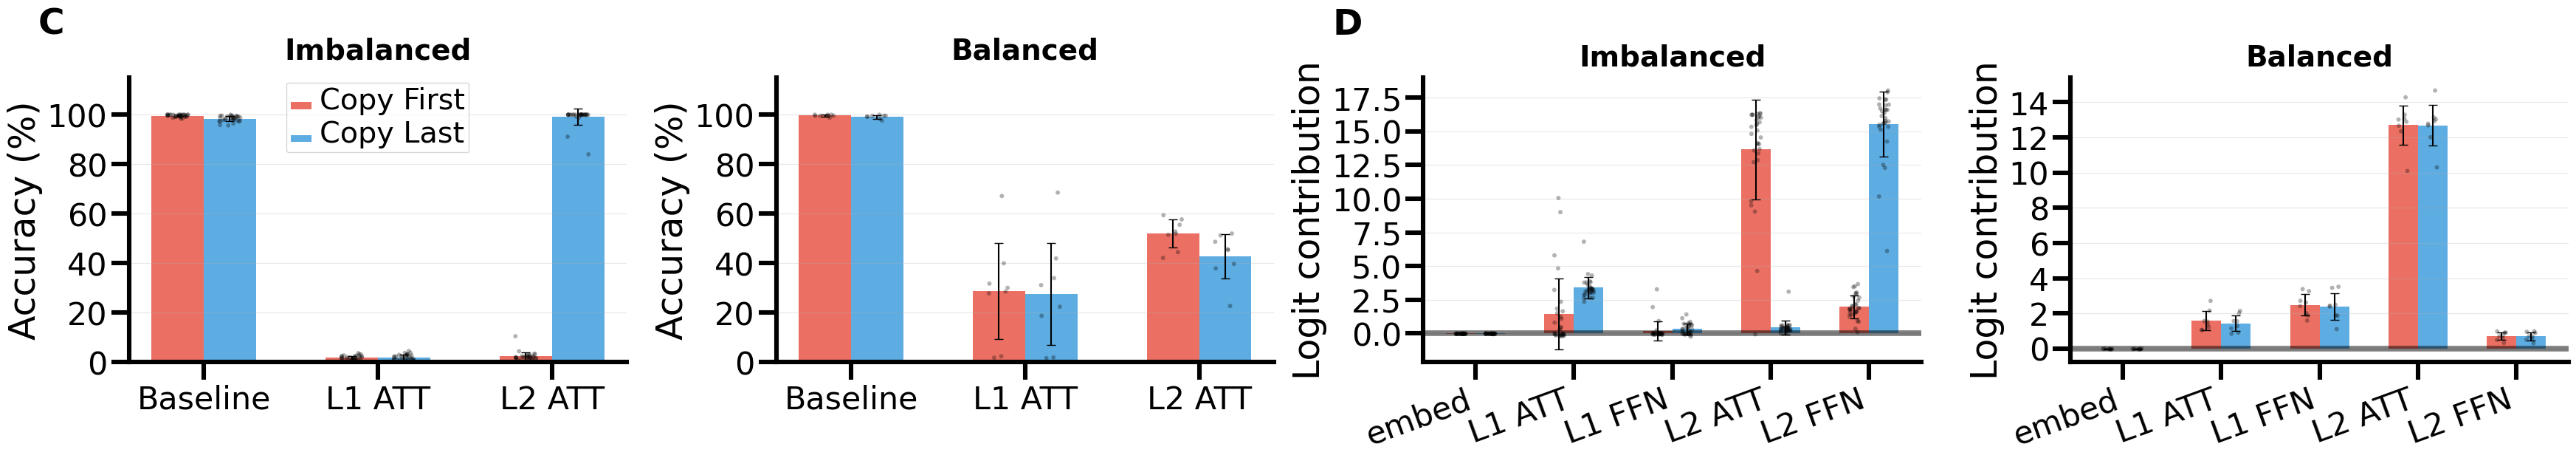

In [29]:
# ── Combined Ablation + DLA Figure (1 × 4) ───────────────────────────────────
# Ordered by analysis type:
# [Ablation curriculum, Ablation interleaved, DLA curriculum, DLA interleaved]

fracs = sorted(attr_data.keys())

# Assumes sorted(fracs)[0] = curriculum and sorted(fracs)[1] = interleaved,
# matching the logic in your original figure.
regime_info = [
    (fracs[0], "Imbalanced"),
    (fracs[1], "Balanced"),
]

comp_keys = [
    k for k in attr_data[fracs[0]]["seeds"][0].keys()
    if k not in ("cf_idx", "cl_idx")
]

def _bump_block_label(k):
    # Convert e.g. 'block0_attn' -> 'B1 ATT', 'block1_ffn' -> 'B2 FFN'
    s = k.replace("_attn", " ATT").replace("_ffn", " FFN")
    import re
    return re.sub(r"block(\d+)", lambda m: f"L{int(m.group(1)) + 1}", s)

comp_labels = [_bump_block_label(k) for k in comp_keys]

fig, axes = plt.subplots(1, 4, figsize=(35, 6.5))

# Axes:
# 0 = Ablation curriculum
# 1 = Ablation interleaved
# 2 = DLA curriculum
# 3 = DLA interleaved

# ── Ablation panels: axes[0], axes[1] ────────────────────────────────────────
for col_i, (frac, regime_label) in enumerate(regime_info):
    ax_abl = axes[col_i]

    entry = all_analysis[frac]
    seed_analysis = entry["seed_analysis"]
    meta = seed_analysis[0]["meta"]
    conds = meta["abl_conditions"]
    n_seeds = len(seed_analysis)

    keep_idx = [
        i for i, c in enumerate(conds)
        if c is None or c.endswith("_attn")
    ]

    cond_labels = []
    for i in keep_idx:
        c = conds[i]
        if c is None:
            cond_labels.append("Baseline")
        else:
            parts = c.split("_")
            cond_labels.append(f"L{int(parts[0].replace('block', '')) + 1} ATT")

    cf_arr = (
        np.stack([sr["ablations"]["copy_first_acc"] for sr in seed_analysis])
        [:, keep_idx] * 100
    )
    cl_arr = (
        np.stack([sr["ablations"]["copy_last_acc"] for sr in seed_analysis])
        [:, keep_idx] * 100
    )

    x = np.arange(len(keep_idx))
    width = 0.3

    cf_mean, cf_std = cf_arr.mean(0), cf_arr.std(0)
    cl_mean, cl_std = cl_arr.mean(0), cl_arr.std(0)

    print(f"Ablation {regime_label} ({frac}): CF means = {cf_mean}, CL means = {cl_mean}")

    ax_abl.bar(
        x - width / 2,
        cf_mean,
        width,
        yerr=cf_std,
        capsize=4,
        label="Copy First",
        color="#e74c3c",
        alpha=0.8,
        error_kw={"linewidth": 1.5},
    )
    ax_abl.bar(
        x + width / 2,
        cl_mean,
        width,
        yerr=cl_std,
        capsize=4,
        label="Copy Last",
        color="#3498db",
        alpha=0.8,
        error_kw={"linewidth": 1.5},
    )

    rng = np.random.default_rng(0)
    for seed_i in range(n_seeds):
        jitter = rng.uniform(-0.06, 0.06)
        ax_abl.scatter(
            x - width / 2 + jitter,
            cf_arr[seed_i],
            color="black",
            s=18,
            alpha=0.3,
            zorder=5,
            edgecolors="none",
        )
        ax_abl.scatter(
            x + width / 2 + jitter,
            cl_arr[seed_i],
            color="black",
            s=18,
            alpha=0.3,
            zorder=5,
            edgecolors="none",
        )
    ax_abl.set_xticks(x)
    ax_abl.set_xticklabels(cond_labels, fontsize=15)
    ax_abl.set_ylim(0, 115)
    ax_abl.set_ylabel("Accuracy (%)", fontsize=20)

    if col_i == 0:
        ax_abl.legend(fontsize=10)

    ax_abl.grid(axis="y", alpha=0.3)
    ax_abl.tick_params(axis="both", labelsize=14)
    format_axis(ax_abl, line_width_multiplier=2.2, font_size_multiplier=2.2)
    ax_abl.set_title(regime_label, fontsize=28, fontweight="bold", pad=18)


# ── DLA panels: axes[2], axes[3] ─────────────────────────────────────────────
for col_i, (frac, regime_label) in enumerate(regime_info):
    ax_dla = axes[col_i + 2]

    d = attr_data[frac]
    seeds = d["seeds"]

    cf_means = np.stack([
        [s[k][s["cf_idx"]].mean() for k in comp_keys]
        for s in seeds
    ])
    cl_means = np.stack([
        [s[k][s["cl_idx"]].mean() for k in comp_keys]
        for s in seeds
    ])

    x = np.arange(len(comp_keys))
    width = 0.3

    cf_m, cf_s = cf_means.mean(0), cf_means.std(0)
    cl_m, cl_s = cl_means.mean(0), cl_means.std(0)

    print(f"DLA {regime_label} ({frac}): CF means = {cf_m}, CL means = {cl_m}")

    ax_dla.bar(
        x - width / 2,
        cf_m,
        width,
        yerr=cf_s,
        capsize=4,
        color="#e74c3c",
        alpha=0.8,
        label="Copy First",
        error_kw={"linewidth": 1.5},
    )
    ax_dla.bar(
        x + width / 2,
        cl_m,
        width,
        yerr=cl_s,
        capsize=4,
        color="#3498db",
        alpha=0.8,
        label="Copy Last",
        error_kw={"linewidth": 1.5},
    )

    rng = np.random.default_rng(0)
    for si in range(len(seeds)):
        jitter = rng.uniform(-0.05, 0.05)
        ax_dla.scatter(
            x - width / 2 + jitter,
            cf_means[si],
            color="black",
            s=18,
            alpha=0.3,
            zorder=5,
            edgecolors="none",
        )
        ax_dla.scatter(
            x + width / 2 + jitter,
            cl_means[si],
            color="black",
            s=18,
            alpha=0.3,
            zorder=5,
            edgecolors="none",
        )

    ax_dla.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax_dla.set_xticks(x)
    ax_dla.set_xticklabels(comp_labels, fontsize=15, rotation=20, ha="right")
    ax_dla.set_ylabel("Logit contribution", fontsize=20)

    ax_dla.grid(axis="y", alpha=0.3)
    ax_dla.tick_params(axis="both", labelsize=14)
    format_axis(ax_dla, line_width_multiplier=2.2, font_size_multiplier=2.2)
    ax_dla.set_title(regime_label, fontsize=28, fontweight="bold", pad=12)


plt.tight_layout()
fig.subplots_adjust(wspace=0.3, top=0.80)

# ── Spanning panel letters only: C for ablation pair, D for DLA pair ─────────
def add_spanning_panel_label(label, left_ax, right_ax, y_offset=0.075):
    left = left_ax.get_position().x0
    right = right_ax.get_position().x1
    top = max(left_ax.get_position().y1, right_ax.get_position().y1)

    fig.text(
        left - 0.035,
        top + y_offset,
        label,
        ha="left",
        va="bottom",
        fontsize=35,
        fontweight="bold",
        color="black",
    )

add_spanning_panel_label("C", axes[0], axes[1])
add_spanning_panel_label("D", axes[2], axes[3])
plt.show()